# FlowTopo quick start

Builds the eight reusable structures on the bundled example basin — three
serial orderings, three parallel layerings, two spatial partitions — checks
the write-conflict guarantee, and runs the four kernels that exercise them.
Everything here runs on the data in the repository; nothing has to be
downloaded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import flowtopo

topo = flowtopo.FlowTopo.from_raster("../data/dir_example.tif")
topo


FlowTopo(shape=(292, 614), ncells=93432, nbasins=1)

## The three serial orderings

Each is a topologically sorted list of every valid cell.  Mapped here as the
position each cell holds in the sequence, headwaters first.


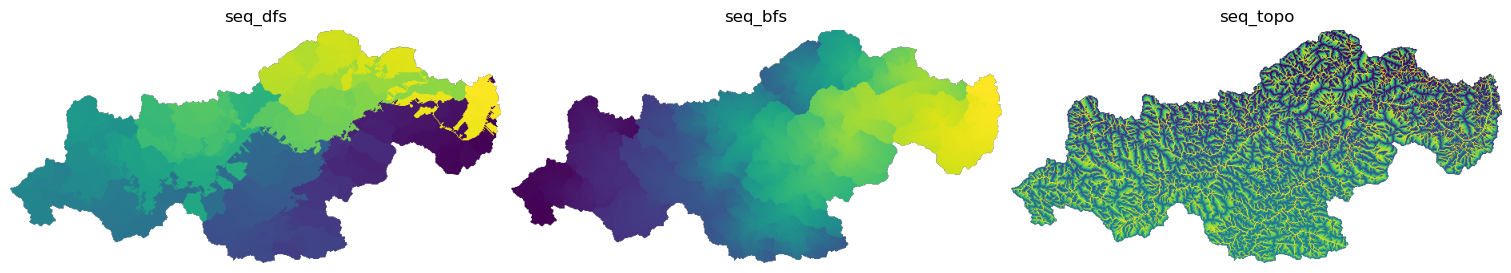

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), constrained_layout=True)
for ax, name in zip(axes, ["dfs", "bfs", "topo"]):
    seq = topo.ordering(name, "u2d")
    position = np.full(topo.idxs_ds.size, np.nan)
    position[seq] = np.arange(seq.size)
    ax.imshow(topo.to_2d(position), cmap="viridis")
    ax.set_title(f"seq_{name}")
    ax.axis("off")


## The three parallel layerings

One layer index per cell.  Cells inside a layer are mutually independent.


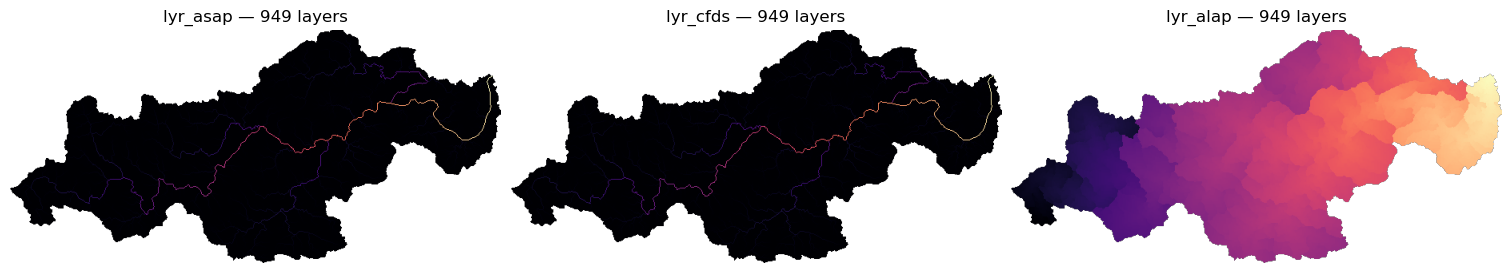

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), constrained_layout=True)
for ax, name in zip(axes, ["asap", "cfds", "alap"]):
    layers, nlayers = topo.layering(name)
    shown = np.where(topo.mask, layers, np.nan)
    ax.imshow(topo.to_2d(shown), cmap="magma")
    ax.set_title(f"lyr_{name} — {nlayers} layers")
    ax.axis("off")


## The guarantee, counted

A push writes into the receiver.  Inside a layer that is safe only if no two
cells share one.  This counts how often they do, which is a property of the
layering rather than of any particular run.


In [4]:
def conflicts(layering):
    total = 0
    for members in topo.decomposition(layering, "u2d"):
        ds = topo.idxs_ds[members]
        ds = ds[(ds >= 0) & (ds != members)]
        total += ds.size - np.unique(ds).size
    return total

for name in ("asap", "cfds", "alap"):
    print(f"{name:5s} {conflicts(name):>8,} receivers written twice in one layer")


asap    12,122 receivers written twice in one layer
cfds         0 receivers written twice in one layer
alap    39,130 receivers written twice in one layer


Only the conflict-free downstream layering reaches zero.  Under the other two,
a plain push loses writes — deterministically here, because numpy's
`a[idx] += v` keeps only the last write when `idx` repeats, which is the same
failure a non-atomic threaded push has.


In [5]:
reference = topo.upstream_area(ordering="dfs")

for name in ("asap", "cfds", "alap"):
    pushed = topo.upstream_area(layering=name, manner="push")
    worst = np.abs(pushed[topo.mask] - reference[topo.mask]).max()
    print(f"{name:5s} push: worst error {worst:10.4f} km2")


asap  push: worst error   175.2186 km2
cfds  push: worst error     0.0027 km2
alap  push: worst error   731.0199 km2


## The two spatial partitions

A layering spreads a layer across threads that share memory. Running on
several processors needs a second cut, and it has to follow the drainage
hierarchy so no value crosses a subregion boundary mid-kernel. Set
`n_parts` to the number of processors.


In [6]:
for level in ("basin", "subbasin"):
    part, load = topo.partition(n_parts=4, level=level)
    stem = np.count_nonzero(part == flowtopo.MAINSTEM)
    print(f"{level:9s} {load.astype(int)}  imbalance {load.max()/load.mean():.2f}"
          f"  mainstem {stem}")


basin     [93432     0     0     0]  imbalance 4.00  mainstem 0
subbasin  [23121 23121 23121 23120]  imbalance 1.00  mainstem 949


The bundled example is a single basin, so whole-basin assignment cannot
split it and three processors sit idle. Subbasin-level cuts it along the
mainstem and balances. The mainstem depends on its tributaries, so it is
marked `flowtopo.MAINSTEM` and runs in a second stage.


values crossing a subregion boundary: 0


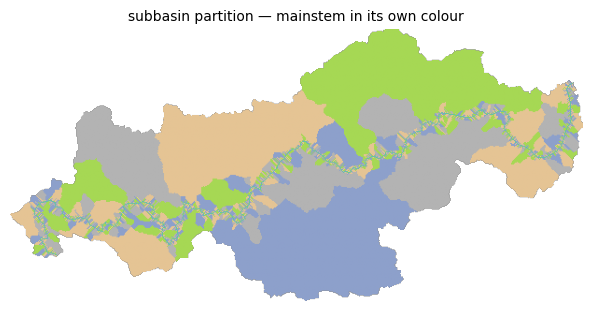

In [7]:
part, _ = topo.partition(n_parts=4, level="subbasin")
shown = np.where(part >= 0, part, np.nan)
shown = np.where(part == flowtopo.MAINSTEM, -1, shown)

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
im = ax.imshow(topo.to_2d(shown), cmap="Set2")
ax.set_title("subbasin partition — mainstem in its own colour", fontsize=10)
ax.axis("off")

cells = np.nonzero(part >= 0)[0]
ds = topo.idxs_ds[cells]
moving = (ds >= 0) & (ds != cells)
crossing = np.count_nonzero(
    (part[ds[moving]] != part[cells[moving]])
    & (part[ds[moving]] != flowtopo.MAINSTEM))
print(f"values crossing a subregion boundary: {crossing}")


## The four kernels


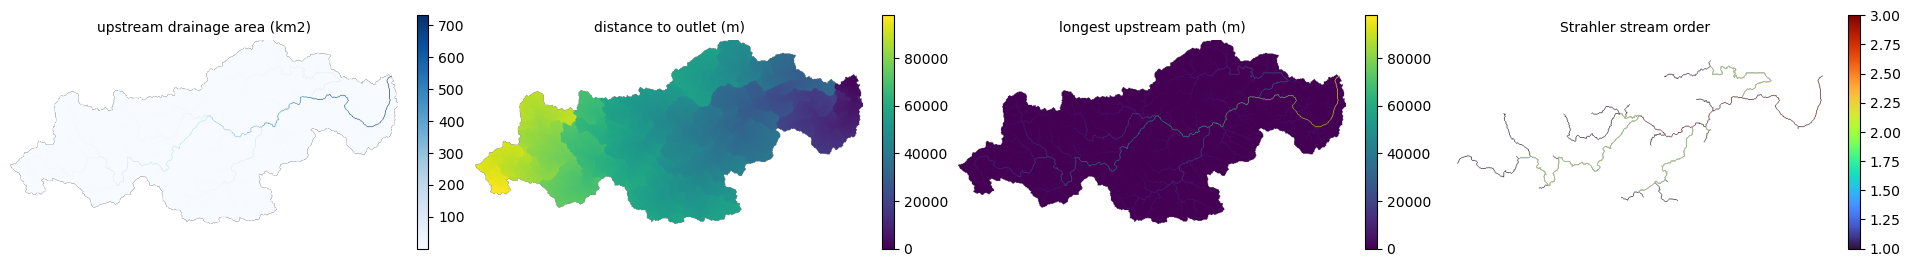

In [8]:
upa = topo.upstream_area(ordering="dfs")
ldn = topo.distance_to_outlet(ordering="dfs")
lup = topo.longest_upstream_path(ldn, ordering="dfs")
channel = topo.channel_mask(upa, 10.0)
ordr = topo.strahler_order(ordering="dfs", channel_mask=channel)

fig, axes = plt.subplots(1, 4, figsize=(19, 3), constrained_layout=True)
panels = [
    (upa, "upstream drainage area (km2)", "Blues", topo.mask),
    (ldn, "distance to outlet (m)", "viridis", topo.mask),
    (lup, "longest upstream path (m)", "viridis", topo.mask),
    (ordr.astype(float), "Strahler stream order", "turbo", channel),
]
for ax, (data, title, cmap, where) in zip(axes, panels):
    shown = np.where(where, data, np.nan)
    im = ax.imshow(topo.to_2d(shown), cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)


## Every manner agrees

Drainage area and longest upstream path are not expected to agree bit for bit:
floating-point addition is not associative and each manner sums a confluence's
donors in a different order.


In [9]:
print(f"{'layering':10s} {'manner':12s} {'worst error (km2)':>18s}")
for name in ("asap", "cfds", "alap"):
    for manner in ("pull", "atomic_push"):
        value = topo.upstream_area(layering=name, manner=manner)
        worst = np.abs(value[topo.mask] - reference[topo.mask]).max()
        print(f"{name:10s} {manner:12s} {worst:18.6f}")


layering   manner        worst error (km2)
asap       pull                   0.000000
asap       atomic_push            0.002747
cfds       pull                   0.000000
cfds       atomic_push            0.002747
alap       pull                   0.000000
alap       atomic_push            0.002808


## Memory locality

The interleaved (cell, receiver) access stream fed through a simulated N-way
set-associative LRU cache.


In [10]:
print(f"{'structure':10s} {'L1 miss':>10s} {'row jump':>10s}")
for name in ("dfs", "bfs", "topo"):
    m = topo.serial_locality(name, levels=("L1",))
    print(f"seq_{name:6s} {100 * m['miss_rate_L1']:9.4f}% {m['row_jump_frac']:10.4f}")
for name in ("asap", "cfds", "alap"):
    m = topo.parallel_locality(name, levels=("L1",))
    print(f"lyr_{name:6s} {100 * m['miss_rate_L1']:9.4f}% {'-':>10s}")


structure     L1 miss   row jump
seq_dfs      10.5494%     0.8658
seq_bfs      21.8304%     0.6199
seq_topo     37.0196%     0.3138
lyr_asap     37.0512%          -
lyr_cfds     41.9628%          -
lyr_alap     21.7807%          -


## Where to go next

* [`docs/user-guide.md`](../docs/user-guide.md) — how to choose an ordering, a
  layering and a manner, and how to run the threaded kernels.
* [`docs/methods.md`](../docs/methods.md) — every construction, its origin and
  its cost.
* `python ../example.py` — the same checks as a script, with a PASS/FAIL verdict.
